# Biology 1C: Discovery, Week 5 Workshop

Prepare to analyse entire session's data!

Note, this material follows on from some material in Variation 1A weeks 3 and 10. Please review this material before the workshop!

- Week 3: descriptive statistics, population means, etc.
- Week 10: Comparing 2 population means
- Find it on the LEARN page for Variation
- Or, find self-study notebooks at https://github.com/edinburgh-bto/Variation1/tree/main/Self-study%20Notebooks 

# Variability in colony counts

Overall, we are trying to understand variation in colony counts. We will use this to understand how we choose a dilution, and how we compare two related sets of colony counts, to ask quantitative questions like "How many (cultivatable) microbes are there per gram of soil", and "Does nutrient limited media help to cultivate more bacteria from soil?"


## Load the python packages and functions needed for the workshop

We will load the packages and define functions to simulate experiments of colony counts.

The plan for this week's workshop is to first use the functions in the context of statistical exploration. Then to return at the end to understanding the functions, after we have a sense for what they do.

To get going with the workshop, please just run these code chunks now, and start working on simulated experiment 2.

In [1]:
# first load python packages
import pandas as pd # pandas data frames
import numpy as np # numpy for various calculations
from scipy import stats # statistics functions
import math  # for the square root function
import seaborn as sns # friendly plotting functions including histograms
import matplotlib.pyplot as plt # other plotting functions including subplots and axis lines

# start a numpy random number generator
rng = np.random.default_rng(seed = 2026)

In [2]:
# functions to generate random points that look like colonies on a petri dish

def generate_random_points(radius, x_centre, y_centre, size = 1):
    # Generate random points uniformly distributed on a circle
    #
    # Random angle, uniformly at random (0 to 2*pi)
    theta = rng.uniform(0, 2 * math.pi, size)
    # Random radius, square root of uniform distribution
    r = radius * np.sqrt(rng.uniform(0, 1, size))
    
    # Calculate Cartesian coordinates x,y from the angle and radius
    x = x_centre + r * np.cos(theta)
    y = y_centre + r * np.sin(theta)
    return x, y

# Example usage
# generate_random_points(radius = 0, x_c = 10, y_c = 10, size = 10))

def plot_random_petridish(n, dishcolour = 'lightgrey', ax = None):
    # generate points first
    points = generate_random_points(radius = 45, x_centre = 0, y_centre = 0, size = n)
    # seaborn example - temporarily discarded
    # ax = sns.scatterplot(x = points[0], y = points[1])
    # Here using matplotlib as flexible on plotting order
    # set up the plot, if no plot axis supplied. 
    if ax is None :
        fig, ax = plt.subplots()
    circle = plt.Circle(xy = (0, 0), radius = 45, color = dishcolour, fill = True, linewidth = 1)
    ax.add_patch(circle)
    ax.scatter(x = points[0], y = points[1])
    # remove axis labels etc. so just a picture of a circle
    ax.set_axis_off()
    # Ensure circle is not distorted, by setting equal x/y aspect ratio
    ax.set_aspect('equal', adjustable='box')
    ax

# Example usage
# plot_random_petridish(100)

In [3]:
# functions to simulate colony counts, we'll use for our simulated experiments

def countafterdilution(dilution = 0.1, samplesize = 8) :
    # function using random binomial variate generator from numpy
    # with default values: 10-fold dilution for a sample of size 8
    return rng.binomial(n = samplesize, p = dilution)

def countcolonies(dilution,
                  plotplate = True,
                  _secretparameter = np.exp(np.pi * 5), 
                  _secretmaxcount = 200,
                  _secretoverdispersion = 0.05) :
    # the secret parameter is the thing that students are meant to find by in experiment 3
    # don't take a short cut! Yes, the expression used to calculate it is deliberately silly.
    #
    # generate an mean value for number of colonies that is overdispersed
    thismean = _secretparameter * dilution * rng.lognormal(sigma = _secretoverdispersion) 
    # generate a number of colonies from a Poisson distribution with that mean
    ncolonies = rng.poisson(lam = thismean)
    if plotplate :
        plot_random_petridish(ncolonies)
    # replace values over _secretmaxcount with "nan" not a number
    if ncolonies > _secretmaxcount:
        return float('nan')
    else :
        return ncolonies

def count2populations(dilution,
                      plotplate = True,
                  _secretmean1 = np.exp(16.8),
                  _secretmean2 = np.power(2,24),
                  _secretmaxcount = 100,
                  _secretoverdispersion = 0.01) :
    # the secret parameter is the thing that students are meant to find in experiment 4
    # don't take a short cut! Yes, the expressions used to calculate are deliberately silly.
    # 
    # generate a mean value that is "overdispersed" to have a little extra variability
    dilution_variable = dilution * rng.lognormal(sigma = _secretoverdispersion) 
    # generate two numbers of colonies from a Poisson distribution with that mean
    ncolonies1 = rng.poisson(lam = dilution_variable * _secretmean1)
    ncolonies2 = rng.poisson(lam = dilution_variable * _secretmean2)
    #
    # plot two plates 
    if plotplate :
        fig, (ax1, ax2) = plt.subplots(1, 2)
        plot_random_petridish(ncolonies1, dishcolour = 'lightgrey', ax = ax1)
        ax1.set_title('Media 1')
        plot_random_petridish(ncolonies2, dishcolour = 'khaki', ax = ax2)
        ax2.set_title('Media 2')
    #
    # replace values over _secretmaxcount with "nan" not a number
    if ncolonies1 > _secretmaxcount:
        ncolonies1 = float('nan')
    if ncolonies2 > _secretmaxcount:
        ncolonies2 = float('nan')
    return [ncolonies1, ncolonies2]

# FIGURE OUT DATA STRUCTURE NEXT!

1379410.7058059827
67
56
83
71
70


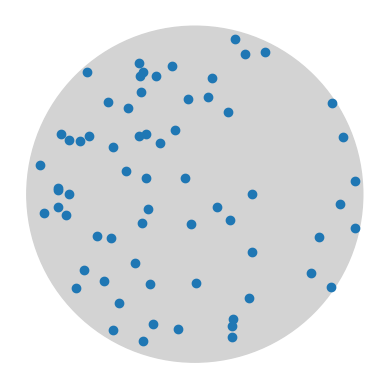

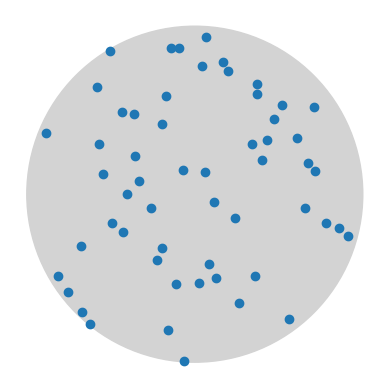

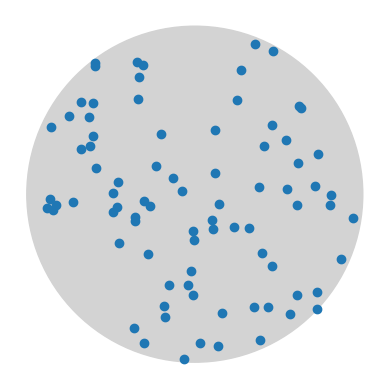

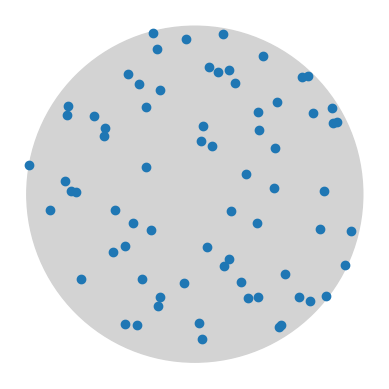

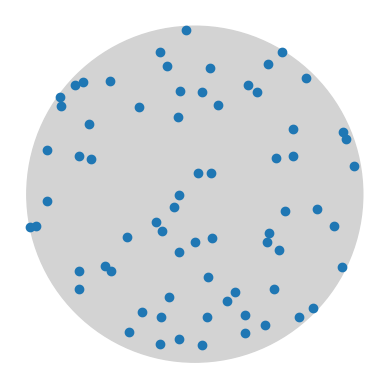

In [4]:
# test code chunk - remove for students
print(np.exp(np.pi * 4.5))

for i in range(5):
    print(countcolonies(dilution = 1e-5))

[20, 19]
[16, 20]
[20, 20]
[23, 7]
[16, 20]


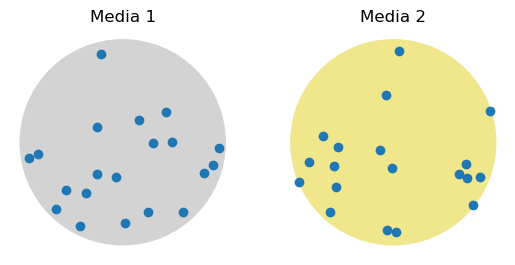

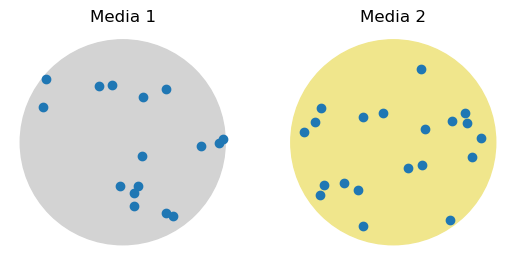

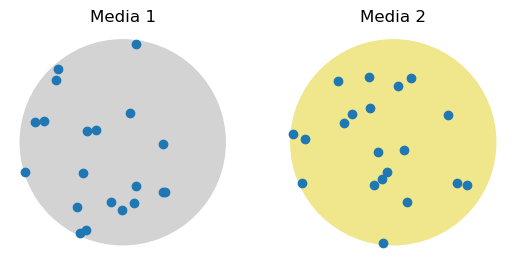

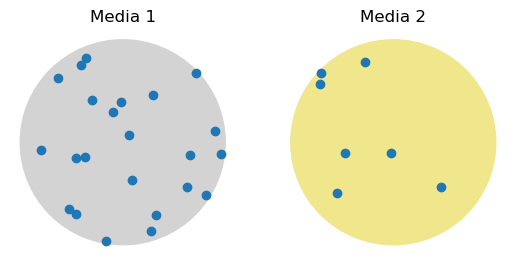

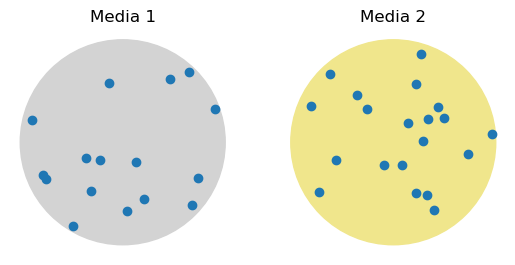

In [5]:
# test code chunk - remove for students
# count2populations(dilution = 1e-7)
for i in range(5):
    print( count2populations(dilution = 1e-6) )

# Simulated experiment 1: sampling variability in serial dilution using 10-sided dice

- Your group has 8 dice
- Each of these represents 1 cell
- If the dice rolls 10, that cell goes in the 10-fold dilution
- Roll all 8 of those dice: how many cells in the dilution?
- Repeat this a total of 10 times. What’s your average?

Discuss in groups:
- What did you expect?
- Did you ever see this mean value in a single sample?
- What range of values did you see?


## Simulated experiment 2: sampling variability on a computer

We are going to do exactly the same simulation as the 10-sided dice, but in this Python notebook.

Then, we will also simulate larger numbers
- more individual samples
- also, samples each of which starts with more cells, “bigger sample size”
- so we understand the big picture of sampling variability


Run this once to see what it does.

In [6]:
countafterdilution()

2

Run this a couple more times, and observe that it's appropriately random, and produces different results different times.

In [7]:
countafterdilution()

1

In [8]:
countafterdilution()

1

Run 10 times to make 10 samples, using a for loop.

In [9]:
tensamples = []

for i in range(10):
    tensamples.append(countafterdilution())

tensamples


[0, 0, 1, 0, 2, 2, 1, 1, 1, 0]

Let's make a histogram to see a picture of the distribution within a sample.

<Axes: ylabel='Count'>

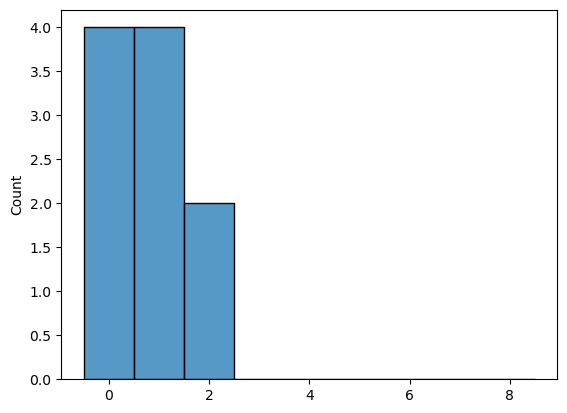

In [10]:
sns.histplot(tensamples, discrete = True, binrange = [0,8])
# "discrete = True" argument is to make the histogram plot centred on whole numbers
# binrange = [0,8] makes the overall range between 0 and 8, consistent with our actual data.

It would help to visualise the mean on the histogram plot. To add this, we will use the matplotlib `axvline` function, and add in red so it's easier to see over the histogram lines.

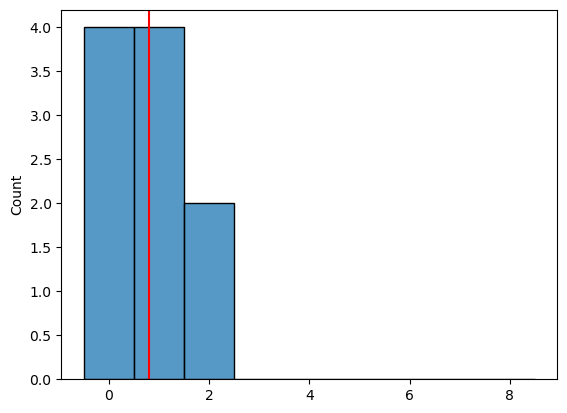

In [11]:
sns.histplot(tensamples, discrete = True, binrange = [0,8])

plt.axvline(np.mean(tensamples), color = "red")

In [12]:
# calculate sample mean and standard error
smean = np.mean(tensamples)
sstd  = np.std(tensamples)

SEM = sstd / math.sqrt(10)   # the standard error of the mean

print(f"sample mean = {smean:.2f}")
print(f'n = {10} samples')
print(f'st.d. = {sstd:.2f} ')
print(f'SEM = {SEM:.2f}')


sample mean = 0.80
n = 10 samples
st.d. = 0.75 
SEM = 0.24


What if we do this again?

Take 2: again, run 10 times to make 10 samples, using a for loop.

In [13]:
tensamples_take2 = []

for i in range(10):
    tensamples_take2.append(countafterdilution())

tensamples_take2

[0, 0, 1, 1, 1, 0, 2, 0, 0, 0]

In [14]:
# calculate sample mean and standard error
smean = np.mean(tensamples_take2)
sstd  = np.std(tensamples_take2)

SEM = sstd / math.sqrt(10)   # the standard error of the mean

print(f"sample mean = {smean:.2f}")
print(f'n = {10} samples')
print(f'st.d. = {sstd:.2f} ')
print(f'SEM = {SEM:.2f}')


sample mean = 0.50
n = 10 samples
st.d. = 0.67 
SEM = 0.21


We see different colony counts when we run the exact same experiment again.

We even, probably, get a different mean - this is the mean of a sample, so that is different on different experiments.

However, the statistics are going to be similar. If we run the experiment many times then "on average, we will see the average".

### Getting bigger, with 100 samples

Let's simulate the experiment that we just did across the whole class with ten-sided dice.

We had (maybe) ten groups, each with ten samples. Let's call that 100 samples total.

In [15]:
hundredsamples = []

for i in range(100):
    hundredsamples.append(countafterdilution())

hundredsamples

[1,
 2,
 1,
 1,
 2,
 2,
 1,
 1,
 3,
 0,
 1,
 1,
 1,
 0,
 0,
 2,
 2,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 3,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 2,
 0,
 1,
 1,
 1,
 2,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 3,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 3,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 2,
 3,
 1,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 2,
 1,
 0,
 1,
 1]

In [16]:
# calculate sample mean and standard error
smean = np.mean(hundredsamples)
sstd  = np.std(hundredsamples)

SEM = sstd / math.sqrt(100)   # the standard error of the mean

print(f"sample mean = {smean:.2f}")
print(f'n = {100} samples')
print(f'st.d. = {sstd:.2f} ')
print(f'SEM = {SEM:.2f}')


sample mean = 0.77
n = 100 samples
st.d. = 0.83 
SEM = 0.08


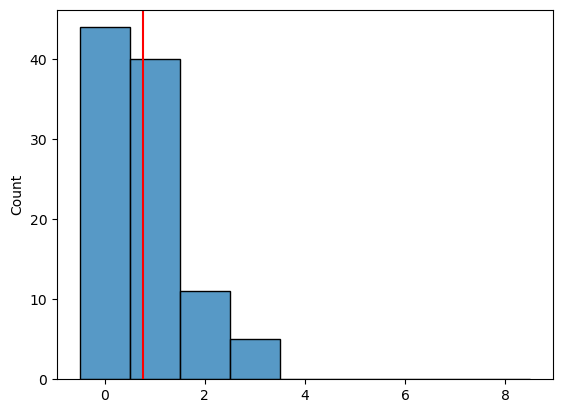

In [17]:
sns.histplot(hundredsamples, discrete = True, binrange = [0,8])
plt.axvline(np.mean(hundredsamples), color = "red")

How does this compare to the results in the class using 10-sided dice?

### Getting bigger, with even more samples

What if we took 10000 (10^4) samples?

Fill in the gaps in the code yourself.

In [18]:
tenthousandsamples = []

for i in range(10000): # edit this out for students
    tenthousandsamples.append(countafterdilution())


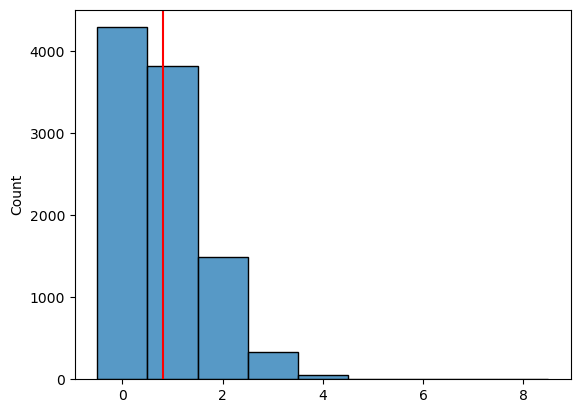

In [19]:
sns.histplot(tenthousandsamples, discrete = True, binrange = [0,8])
plt.axvline(np.mean(tenthousandsamples), color = "red")

In [20]:
# edit this for students
# sample mean and standard error

smean = np.mean(tenthousandsamples)
sstd  = np.std(tenthousandsamples)

SEM = sstd / math.sqrt(10000)

print(f"sample mean = {smean:.2f}")
print(f'n = {10000} samples')
print(f'st.d. = {sstd:.2f} ')
print(f'SEM = {SEM:.2f}')


sample mean = 0.80
n = 10000 samples
st.d. = 0.85 
SEM = 0.01


Notice some important points here.

First, the mean for 10000 samples is really close to the mean we expected, of 0.8.

Second, the distribution looks essentially the same as for 100 samples - so 10000 samples is probably more than we needed to understand the variability.

Third, the standard error of the mean is much smaller for 10000 samples than for 100 samples. This example illustrates that the standard error of the mean scales as $ 1 / \sqrt{n}$. So 10000 samples, we have 10-fold smaller standard error than for 100 samples.



## What if we make each individual sample bigger?

Above, we had all our samples of size 8, like with the 10-sided dice experiment. We took many samples.

We could also take bigger samples - this is like rolling more dice at the same time. In the analogy with dilution of soil samples, this would be like starting with more cells before the dilution.

Let's try this, starting with a sample size of 800 instead of 8. At a tenfold dilution, we would expect a mean of 80.

At this point, we will start leaving gaps in the code for you to fill in.

In [21]:
tensamples_starting800 = []

for i in range(10):
    tensamples_starting800.append(countafterdilution(samplesize = 800))

tensamples_starting800


[87, 86, 84, 92, 71, 89, 73, 72, 81, 84]

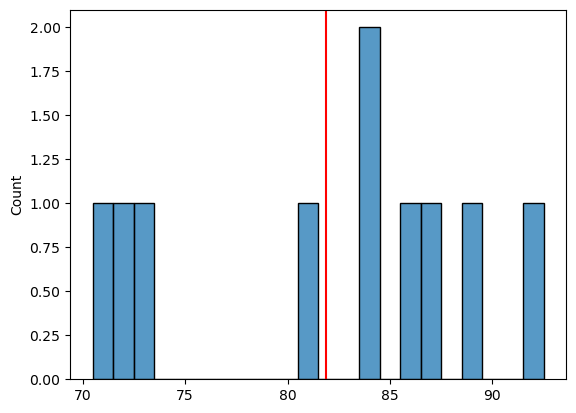

In [22]:
sns.histplot(tensamples_starting800, discrete = True)
plt.axvline(np.mean(tensamples_starting800), color = "red")

In [23]:
# example solved - leave gaps for student version
# sample mean and standard error

smean = np.mean(tensamples_starting800)
sstd  = np.std(tensamples_starting800)

SEM = sstd / math.sqrt(10)

print(f"sample mean = {smean:.2f}")
print(f'n = {10} samples')
print(f'st.d. = {sstd:.2f} ')
print(f'SEM = {SEM:.2f}')


sample mean = 81.90
n = 10 samples
st.d. = 7.08 
SEM = 2.24


Note here that the mean is close to 80, but all the numbers are different. We "only see the average on average".

The standard error of the mean being small, means we are still confident in how close the mean is to 80.

## Try for yourself

You can vary the numbers in the code below - number of samples, dilution, sample size - to see how that affects the mean and distribution.

If you want to try more than one set of different parameters, you can create new code chunks using the "+" (insert a cell below) button, then copy the code into the new chunks and edit that. Alternatively, you can copying and paste entire individual chunks using the copy and paste buttons on Noteable, then edit the code to change parameters.

In [ ]:
mychoiceofsamples = []
mynumberofsamples = ENTERNUMBEROFSAMPLES

for i in range(mynumberofsamples):
    mychoiceofsamples.append(countafterdilution(dilution = ENTERDILUTION, samplesize = ENTERSAMPLESIZE))

mychoiceofsamples


In [ ]:
# calculate sample mean and standard error

smean = np.mean(mychoiceofsamples)
sstd  = np.std(mychoiceofsamples)

SEM = sstd / math.sqrt(mynumberofsamples)

print(f"sample mean = {smean:.2f}")
print(f'n = {mynumberofsamples} samples')
print(f'st.d. = {sstd:.2f} ')
print(f'SEM = {SEM:.2f}')


In [ ]:
sns.histplot(mychoiceofsamples, discrete = True)
plt.axvline(np.mean(mychoiceofsamples), color = "red")

### Statistical concepts at work.

In simulated experiment 2, we showed how to use Python to simulate the numbers of rolls of a dice, itself as a way of thinking through colony counts on a plate.

By simulating data, we can understand its variability. We can also get a hands-on feel for how sample statistics scale with the size of the sample. As the sample size goes up, the standrd error of the mean goes down proportional to the square root of sample size. These ideas inform how to design an experiment for example how many samples to take to estimate the mean accurately.

This is meant to reinforce the ideas about population means covered in Biology 1A: Variation, as well as connecting them to the experiments that you are doing in the labs for Biology 1C: Discovery.


## Simulated experiment 3: how many microbes in a gram of soil?

The function `countcolonies` simulates counting colonies on a petri dish, from a dilution made from 1 gram of soil.
- you give it an argument “dilution”, it returns the number of colonies
- it also prints a picture of a plate with that number of colonies
- but if the number of colonies is greater than 200, it returns “nan” or "not a number" as you can't count that many colonies on a plate
- your mission is to estimate the secret parameter: how many microbes per gram?

Discuss with your group
- How do you decide the right dilution?
- How many samples do you need to take to be confident about the answer?
- What statistical tools can you use?
- How will you visualise your results?
- Then do the “experiment”!

### Reminder on how to write powers of 10 in Python, for dilutions

Python has a useful notation for encoding powers of 10. You can encode `1000` as `1e3` meaning $10^{3}$, `0.01` as `1e-2` meaning $10^{-2}$, and so on. So you will find it easier to try dilutions using this notation. See the example below, and maybe try more for yourself?

In [24]:
# example of dilutions
1e-3

0.001

In [25]:
# try your own here.


### Find a good dilution

First try running `countcolonies` on a range of dilutions. Remember if you don't dilute enough you will get too many colonies and return "nan", and if you dilute too much you will probably get 0.

nan

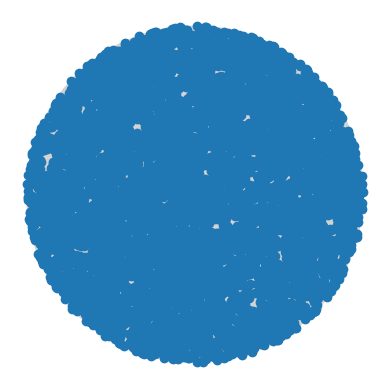

In [26]:
# example solved - edit out dilution for students
countcolonies(dilution = 1e-3)

nan

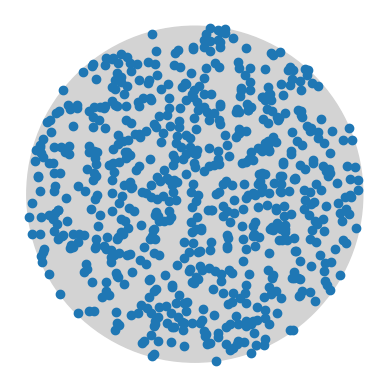

In [27]:
# example solved - edit out dilution for students
countcolonies(dilution = 1e-4)

78

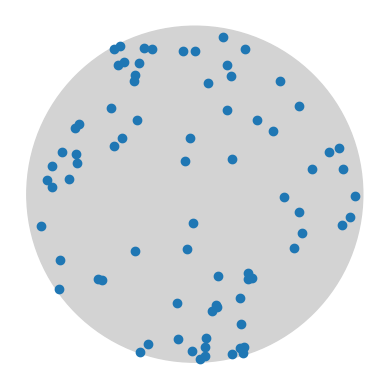

In [28]:
# example solved - edit out dilution for students
countcolonies(dilution = 1e-5)

7

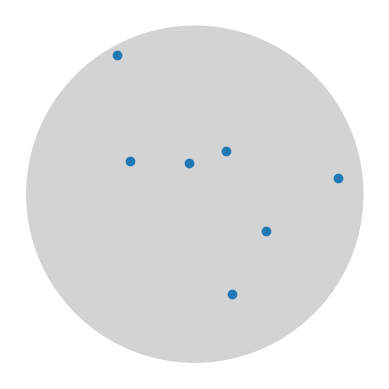

In [29]:
# example solved - edit out dilution for students
countcolonies(dilution = 1e-6)

1

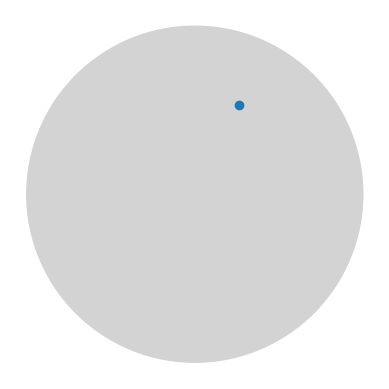

In [30]:
# example solved - edit out dilution for students
countcolonies(dilution = 1e-7)

We can use the same for loop structure here to run many times - even more than the number of petri dishes you would want to plate cells on to.

*Note here we suppress the plotted plate output, so that you don't just plot hundreds of plates and overwhelm the screen.*

In [31]:
# example solved - leave gaps for student version.
samplesforcountcolonies = []
nsamples = 100

for i in range(nsamples):
    samplesforcountcolonies.append(countcolonies(dilution = 1e-5, plotplate = False))

# samplesforcountcolonies

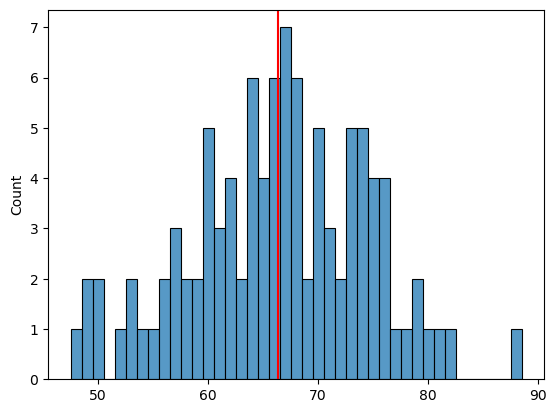

In [32]:
sns.histplot(samplesforcountcolonies, discrete = True)
plt.axvline(np.mean(samplesforcountcolonies), color = "red")

In [33]:
# example solved - leave gaps for student version
# sample mean and standard error

smean = np.mean(samplesforcountcolonies)
sstd  = np.std(samplesforcountcolonies)

SEM = sstd / math.sqrt(nsamples)

print(f"sample mean = {smean:.2f}")
print(f'n = {10} samples')
print(f'st.d. = {sstd:.2f} ')
print(f'SEM = {SEM:.2f}')


sample mean = 66.32
n = 10 samples
st.d. = 8.10 
SEM = 0.81


Overall, you should be able to arrive at an estimate of the mean and standard error of the mean for the number of colonies per gram of soil, by appropriately correcting for the dilution. 

**mean you calculated / dilution** +/- 2 * **sem you calculated / dilution**

Here the statistics you've calculated are on the number of colonies per plate, including the standard error. 

Within your groups, compare:

- your mean and standard error of mean estimates
- their variability
- the dilution you used
- the number of samples you took

What did you learn?

## Simulated experiment 4: comparing 2 populations of microbes

Does nutrient limitation help to cultivate more bacteria from soil?

We have 2 populations of bacteria:
1. a population that grows in media with simple nutrient sources, like LB broth
2. a population that grows in media with complex nutrient, like Starch-Casein media

In this experiment, you take matched samples and ask which numbers are greater.

The function `count2populations` simulates counting colonies on 2 petri dishes, from a dilution made from 1 gram of soil.

- you give it an argument “dilution”, it returns 2 numbers of colonies
- it also displays 2 plates, with the relevant numbers of colonies on them
- but if either number of colonies is greater than a secret threshold*, it returns “nan”

*Note: * Experiment 4 has a different secret threshold from previous experiments, so you'll have to check the dilutions again*

Discuss with your group:

- How do you find the right dilution?
- How many samples do you need to take to be confident about the answer?
- How will you visualise your results?
- Then do the “experiment”!

First, as in experiment 3, get a feel for running `count2populations` at different dilutions, so that you can pick a sensible dilution.

[nan, nan]

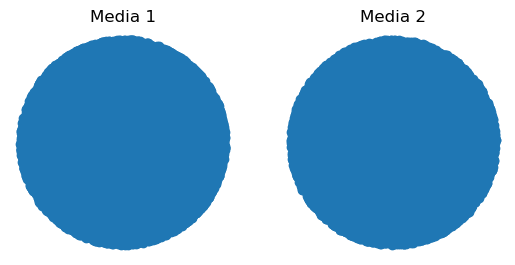

In [34]:
count2populations(dilution = 1e-3)

[nan, nan]

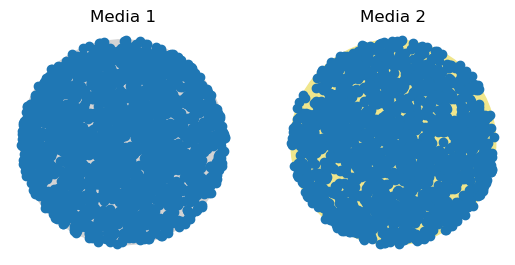

In [35]:
count2populations(dilution = 1e-4)

[nan, nan]

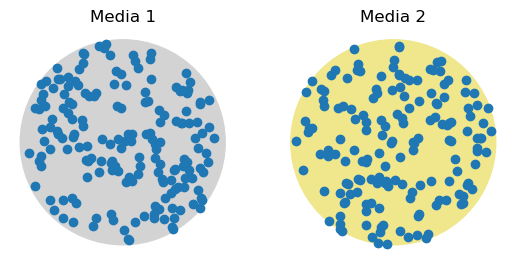

In [36]:
count2populations(dilution = 1e-5)

[12, 21]

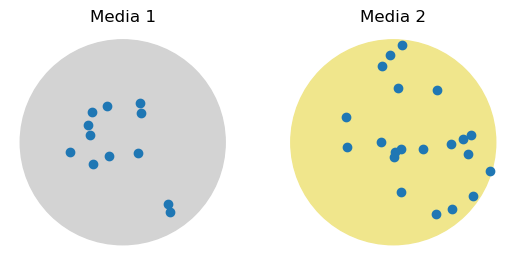

In [37]:
count2populations(dilution = 1e-6)

[2, 0]

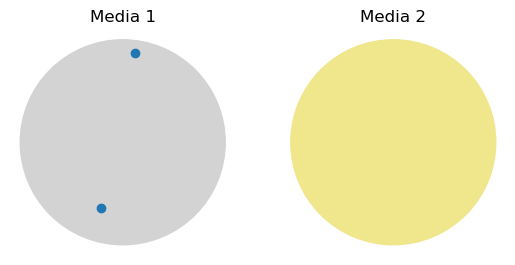

In [38]:
count2populations(dilution = 1e-7)

Next, we'll generate many samples - think of this as many pairs of plates, each pair made from the same dilution.

In the code chunk below we generate samples using the same kind of for loop as we used above, to put the pairs of numbers together in a list.

*Note here we suppress the plotted plate output, so that you don't just plot hundreds of plates and overwhelm the screen.*

In [39]:
# give code chunk to fill out a pandas dataframe with the 2 populations 
# remove some info (dilution, number of samples) from student version

nsamples = 10

samples2popsaslist = []
for i in range(nsamples) :
    samples2popsaslist.append( count2populations(dilution = 1e-6, plotplate = False) )

samples2popsaslist

[[16, 18],
 [14, 19],
 [29, 14],
 [21, 13],
 [11, 21],
 [22, 16],
 [22, 20],
 [17, 21],
 [27, 18],
 [25, 22]]

Quick questions to discuss in your group:

- What do you notice about these data?
- How variable are the colony counts?
- Is the first or second count in the pair reliably greater?
- What, roughly, do you expect now for the outcome of a statistical test?

It was easy to generate the data in this format - a list of pairs of numbers, each pair containing both colony counts for one sample. However, this way of organising the data into a list can be difficult to analyse and plot later. Pandas data frames are designed to organise data in a more useful and flexible way.

The code chunk below puts the data into a pandas dataframe.

The code may be ugly, but, the result is nicer.

In [40]:
samples2pops = pd.DataFrame(
    { "sample" : np.arange(nsamples) + 1,
      "count_media1" : [ ct[0] for ct in  samples2popsaslist],
      "count_media2" : [ ct[1] for ct in  samples2popsaslist]
    })

samples2pops

,sample,count_media1,count_media2
0,1,16,18
1,2,14,19
2,3,29,14
3,4,21,13
4,5,11,21
5,6,22,16
6,7,22,20
7,8,17,21
8,9,27,18
9,10,25,22


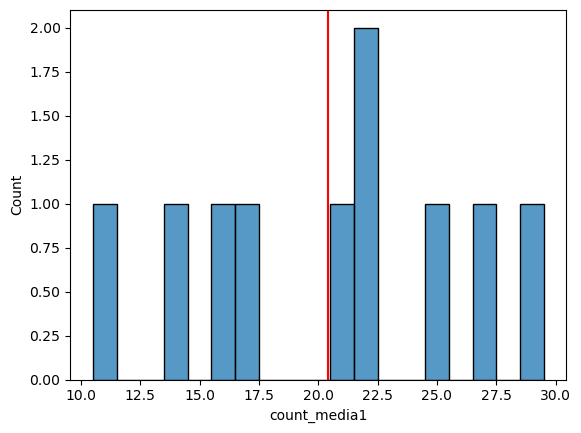

In [41]:
# plot histograms of population1 separately

sns.histplot(data = samples2pops, x = "count_media1", discrete = True)
plt.axvline( samples2pops["count_media1"].mean(), color = "red")

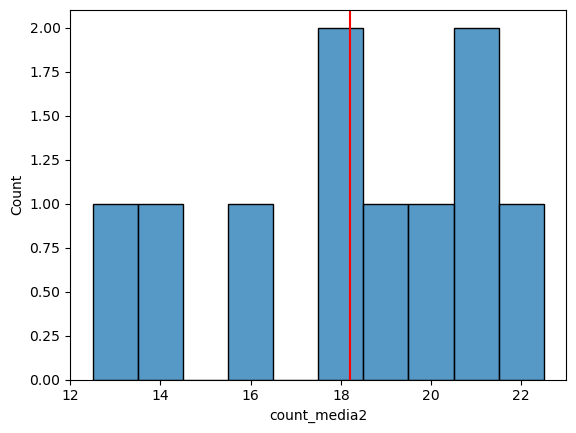

In [42]:
# plot histograms of population1 separately

sns.histplot(data = samples2pops, x = "count_media2", discrete = True)
plt.axvline( samples2pops["count_media2"].mean(), color = "red")

Here, we've plotted the histograms on separate axes. It would be clearer to plot them on matched axes, with the same axis limits and labels, and lined up vertically.

The code below does that. You will have to choose which limits (minimum and maximum value) to use, based on the range of your observed data.

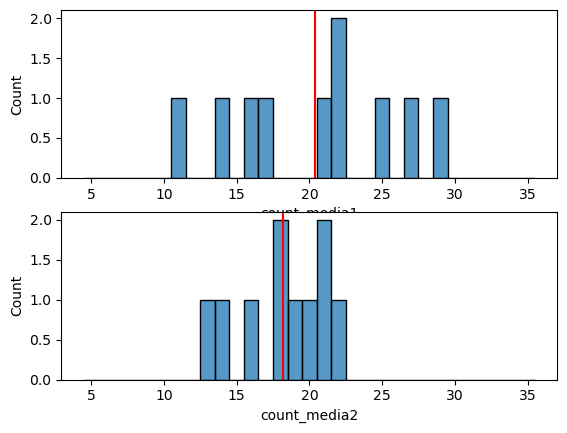

In [43]:
# plot the two population histograms on matched axes.
value_min = 5 # edit out for students
value_max = 35 # edit out for students

fig, (ax1, ax2) = plt.subplots(2)
sns.histplot(data = samples2pops, 
                   x = "count_media1", 
                   discrete = True, 
                   binrange = [value_min, value_max],
            ax = ax1)
ax1.axvline( samples2pops["count_media1"].mean(), color = "red")
sns.histplot(data = samples2pops, 
                   x = "count_media2",
                   discrete = True, 
                   binrange = [value_min, value_max],
                  ax = ax2)
ax2.axvline( samples2pops["count_media2"].mean(), color = "red")

Plotting these lined up should be clearer to interpret.

Now calculate the mean and sems of both populations.

In [44]:
# calculate means and sems of both populations

print(f'n = {nsamples} samples')

# sample means and standard errors
smean1 = samples2pops["count_media1"].mean()
sstd1  = samples2pops["count_media1"].std()
SEM1 = sstd1 / math.sqrt(nsamples)

print(f"sample mean 1 = {smean1:.2f}")
print(f'st.d. 1 = {sstd1:.2f} ')
print(f'SEM1 = {SEM1:.2f}')

smean2 = samples2pops["count_media2"].mean()
sstd2  = samples2pops["count_media2"].std()
SEM2 = sstd2 / math.sqrt(nsamples)

print(f"sample mean 2 = {smean2:.2f}")
print(f'st.d. 2 = {sstd2:.2f} ')
print(f'SEM2 = {SEM2:.2f}')


n = 10 samples
sample mean 1 = 20.40
st.d. 1 = 5.82 
SEM1 = 1.84
sample mean 2 = 18.20
st.d. 2 = 3.05 
SEM2 = 0.96


Reminder here on estimating the difference in population means, as covered in Variation 1A. The key question is how different are the means of the populations, compared to the variability.

In your above calculation of the means and standard errors, you may already have a good sense of this. Write out the sample means and standard errors - are the means more than 2 standard errors apart or not? This "two sems apart" is a good rule of thumb to assess variability of means.

To turn this observation into a rigorous statistical test, we use a test statistic, abbreviated t, which is calculated based on:

$$
t = \frac{\text{difference in sample means}}{\text{variability in sample mean estimates}}
$$

And, reminder that this "variability in sample mean estimates" scales with the standard error of the means.

So t is directly proportional to the difference in the sample means. The larger the difference in the sample means the larger t becomes. The smaller the standard error, for example the larger the number of samples, the larger t becomes.

Now we will do the t-test on these counts.

In [45]:
# use the two sample t-test function from scipy.stats

# Perform the two sample t-test on the colony counts
t, p = stats.ttest_ind( samples2pops["count_media1"], samples2pops["count_media2"])

# Print t 2 decimal places
print(f't = {t:.2f}')

# Print the p-value to 4 decimal places
print(f'p-value = {p:.4f}')

t = 1.06
p-value = 0.3034


Discuss in your groups:

- What do we conclude about growing on media 1 vs media 2, from this t-test?
- Is the difference in numbers big enough to care about in your experimental designs?
- How big a sample size did you use? Could you have come to similar conclusions with a smaller sample?
- Is the needed sample size feasible to test in the lab, with a stack of petri dishes?

If we have time, we will compare the population means and sample sizes across the class.

*Note: there's a feature of the data that we didn't exploit in this analysis, which is that the samples are paired. Each sample was plated on two plates, and in the design these had the same dilution. If there was a lot of variability in dilution, for example from pipetting error, then it would be useful to account for this dilution being shared across the paired plates with different media. There are ways to adapt the statistical analysis to account for the paired data, but we won't cover that this week.*


## Part 5: Data Analysis of colony counts from 1 group

Lastly, let's move even closer to analysing a dataset from the laboratories in this course.

We'll will apply these data analysis ideas to a set of data that might be generated from one group: 

- 6 plates, consisting of
- 3 replicate soil samples from the same source
- each soil sample is diluted and plated on 2 different media
- but here, only for a single dilution

We supply example data in the format of a pandas data frame. (In a real-life scenario you might load this from a spreadsheet, but we're not doing that today.)

In [46]:
# supply 1 group's data as a data frame
counts1group = pd.DataFrame(
    { "sample" : [1,2,3],
      "dilution" : [1e-3, 1e-3, 1e-3],
      "count_LB" : [90, 76, 101],
      "count_SC" : [65, 87, 73]
    })

counts1group

,sample,dilution,count_LB,count_SC
0,1,0.001,90,65
1,2,0.001,76,87
2,3,0.001,101,73


In [47]:
# calculate means and sems of both populations
nsamples = 3
print(f'n = {nsamples} samples')

# sample means and standard errors
smean_LB = counts1group["count_LB"].mean()
sstd_LB  = counts1group["count_LB"].std()
SEM_LB = sstd_LB / math.sqrt(nsamples)

print(f"sample mean LB agar = {smean_LB:.2f}")
print(f'st.d. LB agar = {sstd_LB:.2f} ')
print(f'SEM LB agar = {SEM_LB:.2f}')

smean_SC = counts1group["count_SC"].mean()
sstd_SC  = counts1group["count_SC"].std()
SEM_SC = sstd_SC / math.sqrt(nsamples)

print(f"sample mean SC agar = {smean_SC:.2f}")
print(f'st.d. SC agar = {sstd_SC:.2f} ')
print(f'SEM SC agar = {SEM_SC:.2f}')


n = 3 samples
sample mean LB agar = 89.00
st.d. LB agar = 12.53 
SEM LB agar = 7.23
sample mean SC agar = 75.00
st.d. SC agar = 11.14 
SEM SC agar = 6.43


In [48]:
# use the two sample t-test function from scipy.stats

# Perform the two sample t-test on the colony counts
t, p = stats.ttest_ind( counts1group["count_LB"], counts1group["count_SC"])

# Print t 2 decimal places
print(f't = {t:.2f}')

# Print the p-value to 4 decimal places
print(f'p-value = {p:.4f}')

t = 1.45
p-value = 0.2216


### Now with data from your own group

Use the following code to enter and analyse data from your group.

Note this analysis will only be meaningful if all the data you enter have the same dilution. We will discuss analysing over multiple dilutions another workshop.

In [ ]:
# supply your group's data as a data frame
countsmygroup = pd.DataFrame(
    { "sample" : [1,2,3],
      "dilution" : [ FILLINHERE , , ],
      "count_LB" : [ ANDHERE , , ],
      "count_SC" : [ ANDHERE , , ]
    })

countsmygroup

In [ ]:
# calculate means and sems of both populations
nsamples = CHECKTHIS
print(f'n = {nsamples} samples')

# sample means and standard errors
smean_LB = countsmygroup["count_LB"].mean()
sstd_LB  = countsmygroup["count_LB"].std()
SEM_LB = sstd_LB / math.sqrt(nsamples)

print(f"sample mean LB agar = {smean_LB:.2f}")
print(f'st.d. LB agar = {sstd_LB:.2f} ')
print(f'SEM LB agar = {SEM:.2f}')

smean_SC = countsmygroup["count_SC"].mean()
sstd_SC  = countsmygroup["count_SC"].std()
SEM_SC = sstd_SC / math.sqrt(nsamples)

print(f"sample mean SC agar = {smean_SC:.2f}")
print(f'st.d. SC agar = {sstd_SC:.2f} ')
print(f'SEM SC agar = {SEM_SC:.2f}')


In [ ]:
# use the two sample t-test function from scipy.stats

# Perform the two sample t-test on the colony counts
t, p = stats.ttest_ind( FILLINHERE, FILLINTHISTOO)

# Print t 2 decimal places
print(f't = {t:.2f}')

# Print the p-value to 4 decimal places
print(f'p-value = {p:.4f}')

This week's workshop is meant to teach about statistical principles, and also direct inform how you collect and analyse data in the practical portion of the project and leading up to the group poster.

Discuss in your groups:

- What do we conclude about the number of colonies that grow on LB agar vs SC agar, from this t-test?
- Are the results convincing?
- How many samples or Petri dishes would we need to come to a more reliable conclusion?
- Why do you think the laboratory experimental design involves pooling data across multiple groups?
- What else could we change about the experimental design so that we could obtain reliable statistics?
- How will you present the statistical analysis on your poster?

In later workshops, we will revisit these questions with data from the practicals.


## Optional: understand the simulated experiment code

To understand what's going on "behind the curtain" here, go back to the functions that generate these counts. The main functions to understand are `countafterdilution` (simple) and `countcolonies` (more complex). Those functions are defined in one of the code chunks at the top of this notebook, you can find them or search for them.

To understand these functions:

- read all the parameters that the function uses as input
    - what do they do, where are they used?
- try to run the function with different parameter values
- read through the function line by line, and think about what each line of code does
- read the comments, too
- search for help on individual functions used in the code, e.g. `rng.binomial`
    - check back on what python packages / modules are being used and why
    - for example, trace back that `rng` is defined in a previous code chunk as `rng = np.random.default_rng ...`
- try to run individual lines of code outside the function, and ask what they do
    - change the parameters on these lines, too.
- is there something you think the function could do better? Try it!

You could also move on to understanding the plotting functions, `plot_random_petridish`.

Create more code chunks if you need more space to play around.

In [ ]:
# chunk to play around with countafterdilution



In [ ]:
# chunk to play around with countcolonies



In [ ]:
# chunk to play around with plot_random_petridish

